<a href="https://colab.research.google.com/github/jayparab26/Covid-19-Data-Analysis/blob/main/covid_19(updated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns

# Load dataset
df = pd.read_csv('covid_19_india.csv')

# Data Cleaning

In [22]:
# 1. Convert Date and handle unparseable dates
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Active_Cases'] = df['Confirmed'] - (df['Cured'] + df['Deaths'])

df['Mortality_Rate'] = np.where(df['Confirmed'] > 0, (df['Deaths'] / df['Confirmed']) * 100, 0)

# To drop rows with missing numbers:
df = df.dropna(subset=['Date', 'Confirmed', 'Cured', 'Deaths'])

# Filter subsets for cleaner plotting
df_top5 = df[df['State/UnionTerritory'].isin(['Maharashtra', 'Kerala', 'Karnataka', 'Tamil Nadu', 'Andhra Pradesh'])].copy()

# Aggregate national timeline (dropna=False ensures NaT dates aren't silently lost if you want to inspect them)
national_timeline = df.groupby('Date', dropna=False).sum(numeric_only=True).reset_index()

/tmp/ipykernel_1206/1378731912.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


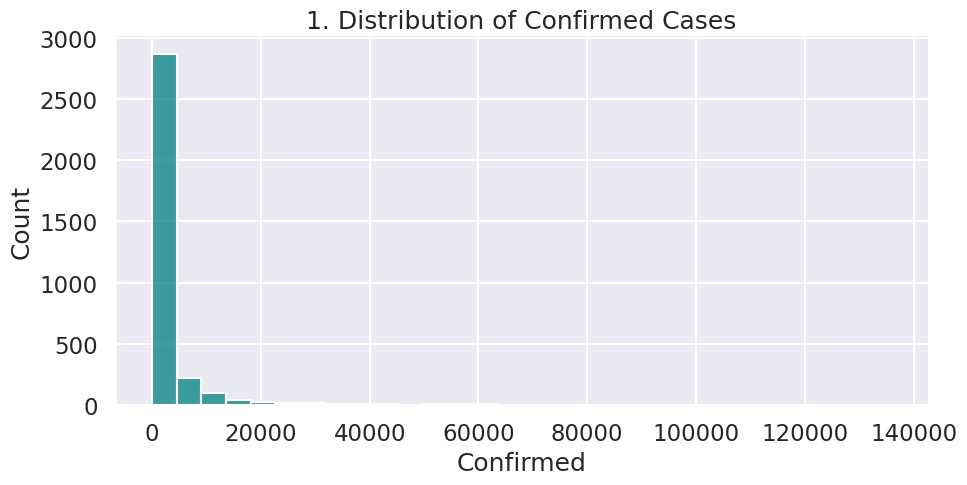

In [38]:
# Query 1 (Confirmed): Distribution of cases

sns.displot(data=df, x='Confirmed', kind='hist', bins=30, color='teal', height=5, aspect=2).set(title="1. Distribution of Confirmed Cases")

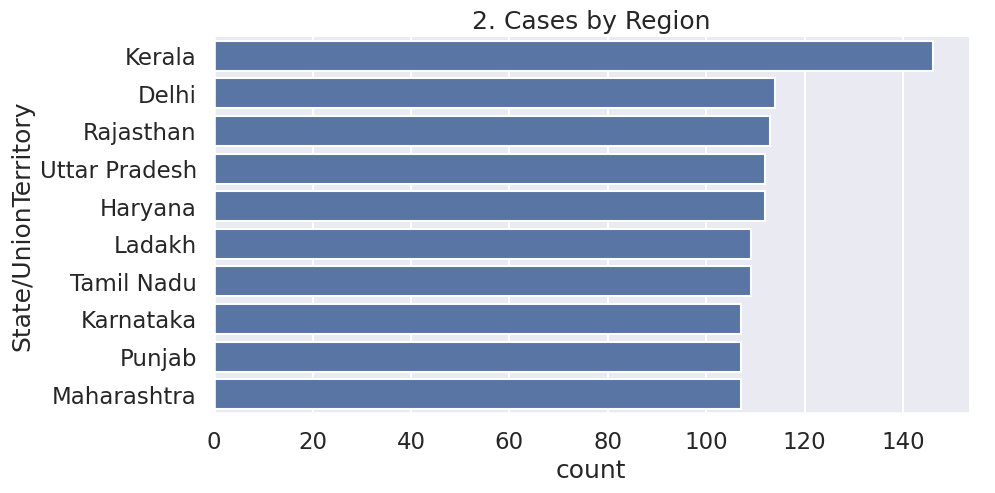

In [37]:
# Query 2 (State/UnionTerritory): Frequency of records by region

sns.catplot(data=df, y='State/UnionTerritory', kind='count', order=df['State/UnionTerritory'].value_counts().index[:10], height=5, aspect=2).set(title="2. Cases by Region")

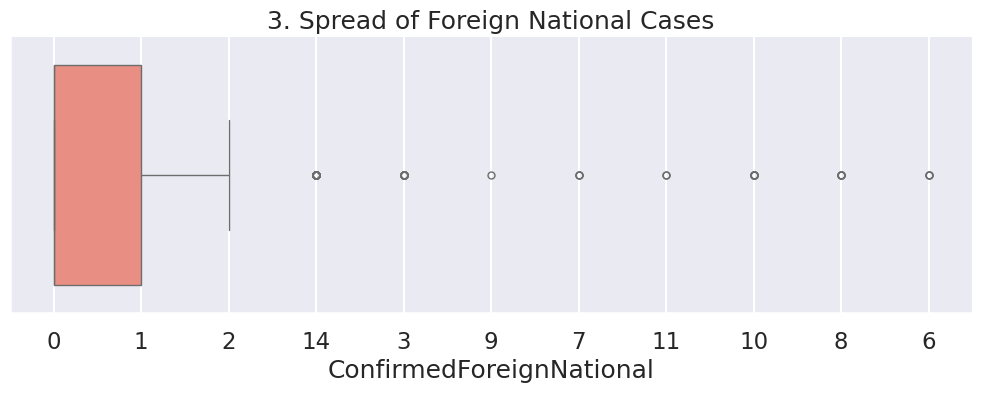

In [25]:
# Query 3 (ConfirmedForeignNational): Range of foreign national cases

sns.catplot(data=df[df['ConfirmedForeignNational'] != '-'], x='ConfirmedForeignNational', kind='box', color='salmon', height=4, aspect=2.5).set(title="3. Spread of Foreign National Cases")

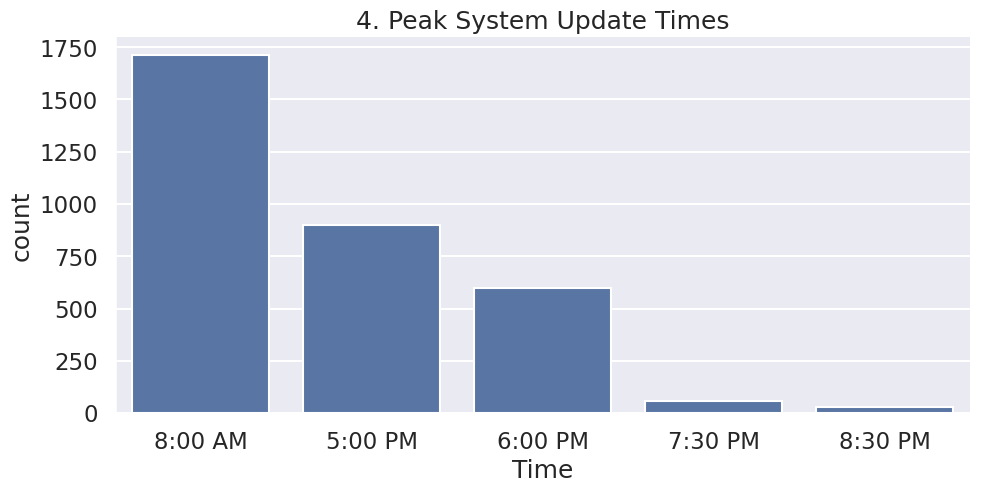

In [26]:
# Query 4 (Time): Distribution of daily reporting hours

sns.catplot(data=df, x='Time', kind='count', order=df['Time'].value_counts().index[:5], height=5, aspect=2).set(title="4. Peak System Update Times")

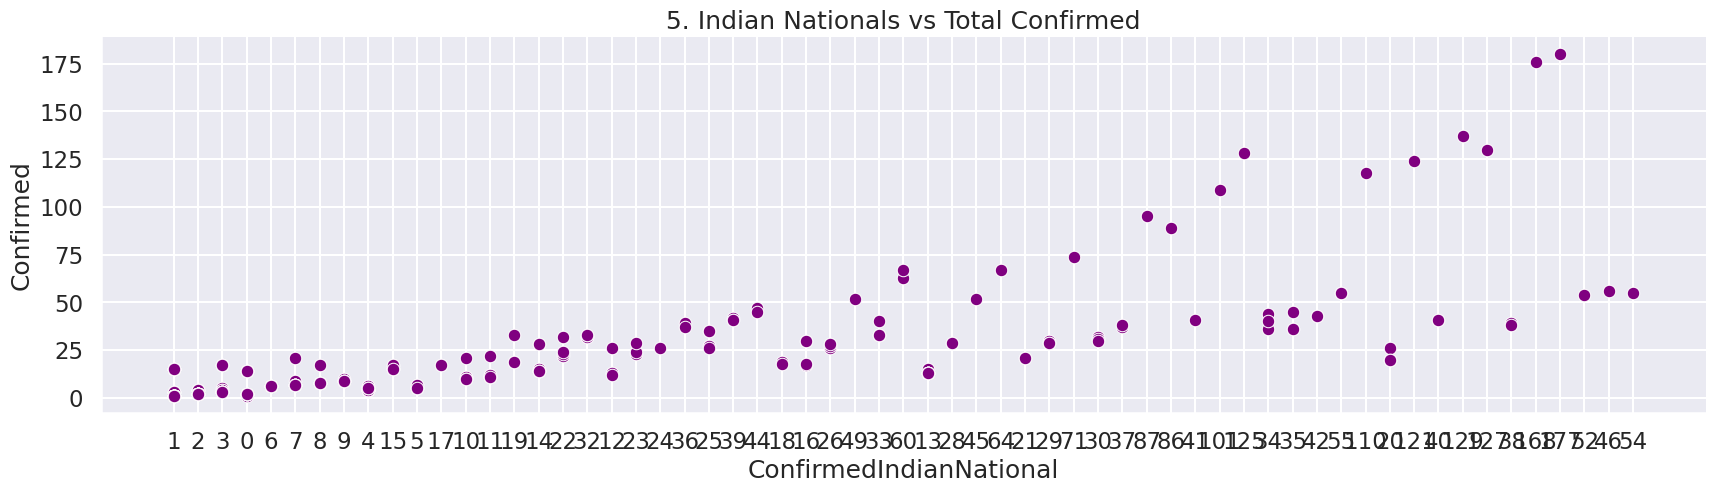

In [28]:
# Query 5 (ConfirmedIndianNational vs Confirmed): Correlation of early tracking metrics

sns.relplot(data=df[df['ConfirmedIndianNational'] != '-'], x='ConfirmedIndianNational', y='Confirmed', kind='scatter', color='purple', height=5, aspect=3.5).set(title="5. Indian Nationals vs Total Confirmed")

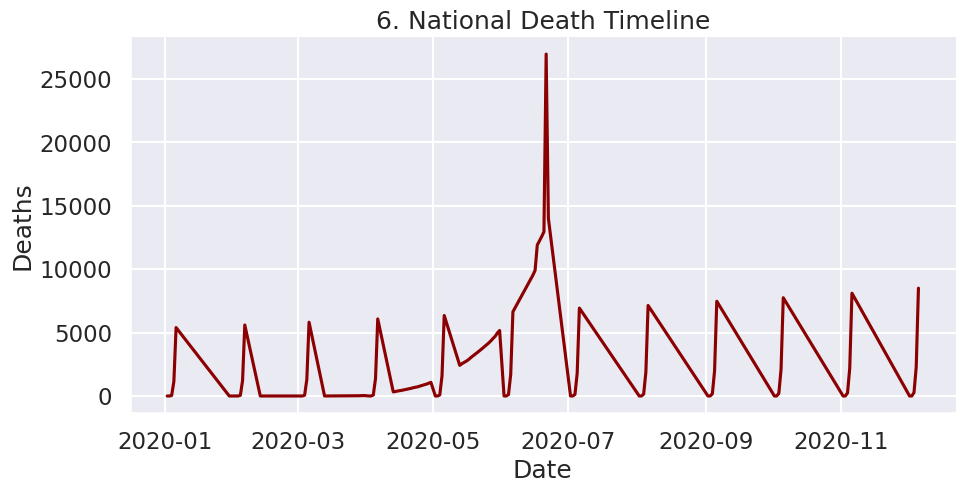

In [29]:
# Query 6 (Date vs Deaths): Cumulative death timeline nationwide

sns.relplot(data=national_timeline, x='Date', y='Deaths', kind='line', color='darkred', height=5, aspect=2).set(title="6. National Death Timeline")

/tmp/ipykernel_1206/3483824440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df.groupby('State/UnionTerritory')['Cured'].max().reset_index().nlargest(10, 'Cured'), x='Cured', y='State/UnionTerritory', kind='bar', palette='viridis', height=5, aspect=2).set(title="7. Highest Recoveries by State")


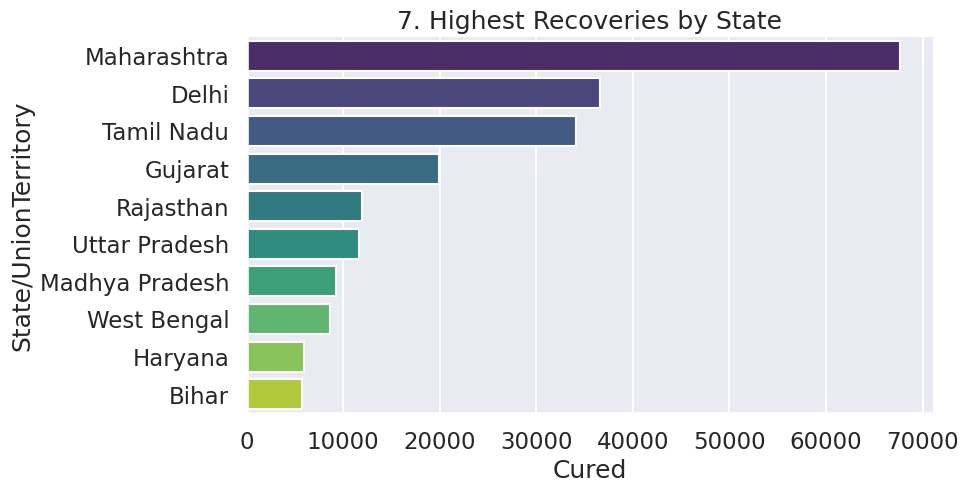

In [30]:
# Query 7 (State/UnionTerritory vs Cured): Top states comparison

sns.catplot(data=df.groupby('State/UnionTerritory')['Cured'].max().reset_index().nlargest(10, 'Cured'), x='Cured', y='State/UnionTerritory', kind='bar', palette='viridis', height=5, aspect=2).set(title="7. Highest Recoveries by State")

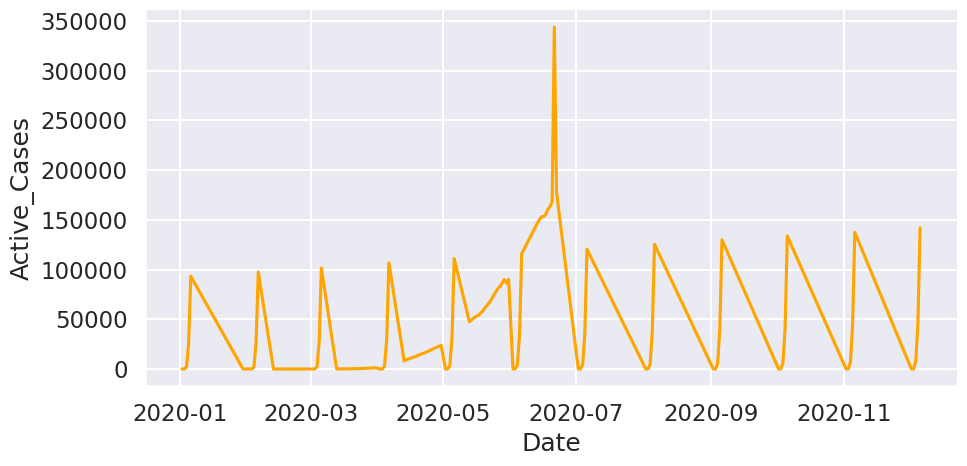

In [31]:
# Query 8 (Date vs Active_Cases): Ongoing healthcare burden

sns.relplot(data=national_timeline, x='Date', y='Active_Cases', kind='line', color='orange', height=5, aspect=2)

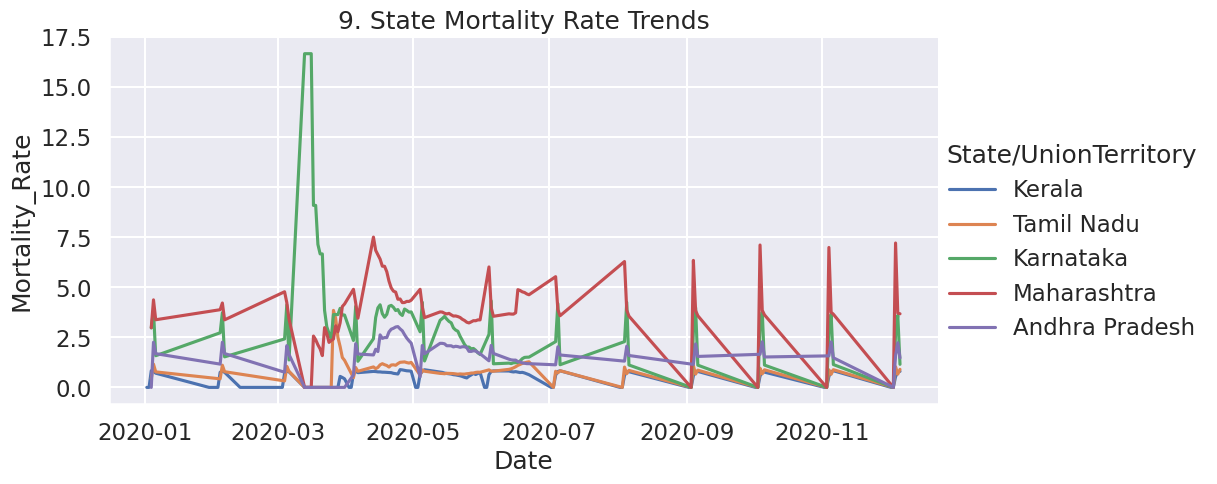

In [32]:
# Query 9 (Mortality_Rate over Time by State): Trend comparison

sns.relplot(data=df_top5, x='Date', y='Mortality_Rate', hue='State/UnionTerritory', kind='line', height=5, aspect=2).set(title="9. State Mortality Rate Trends")

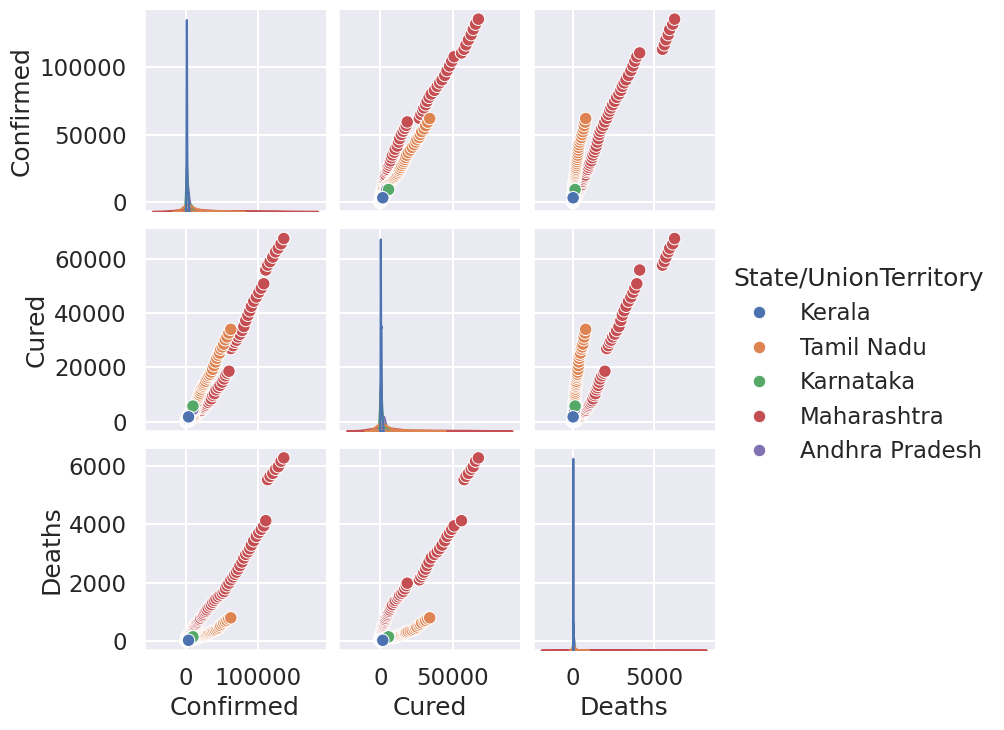

In [33]:
# Query 10 (Pair Grid): Comparative matrix of columns

sns.pairplot(data=df_top5[['Confirmed', 'Cured', 'Deaths', 'State/UnionTerritory']], hue='State/UnionTerritory')

# **Person 6**

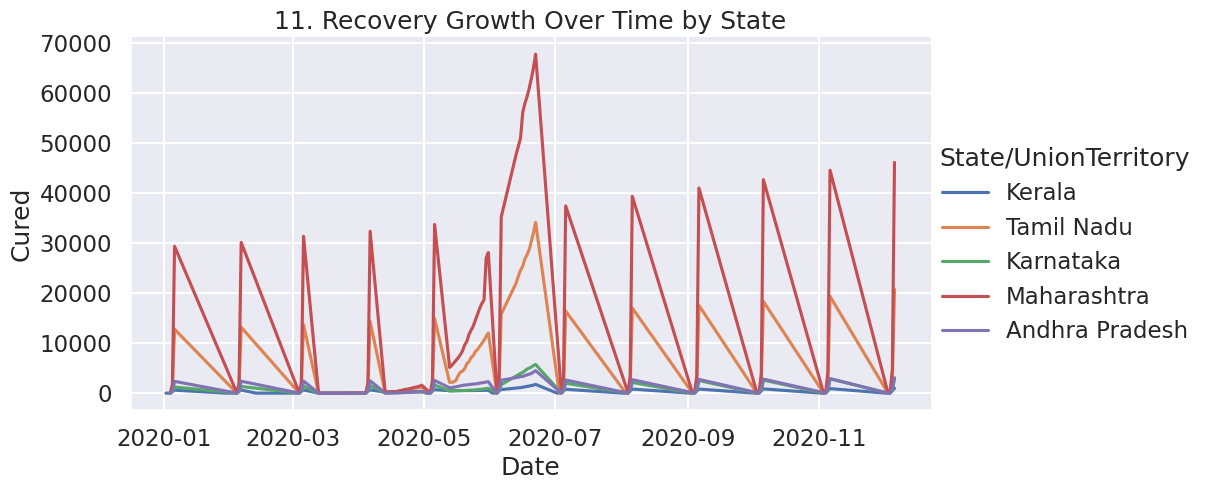

In [34]:
# Query 11 (Cured over Time by State): Progression tracking

sns.relplot(data=df_top5, x='Date', y='Cured', hue='State/UnionTerritory', kind='line', height=5, aspect=2).set(title="11. Recovery Growth Over Time by State")

<Axes: >

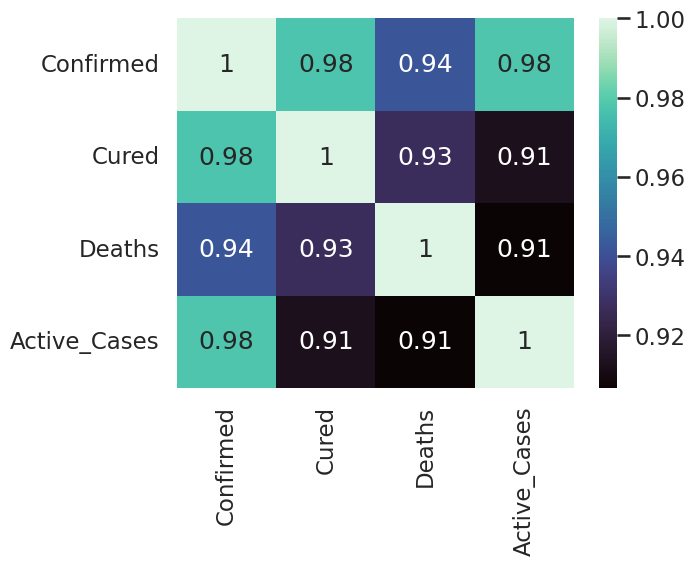

In [35]:
# Query 12 (Correlation Heatmap): Overview matrix

sns.heatmap(data=df[['Confirmed', 'Cured', 'Deaths', 'Active_Cases']].corr(), annot=True, cmap='mako')

# **Prescriptive Analysis**